In [1]:
from ca_sae.sae.ca_sae import ClassAlignedSAE
import torch
import matplotlib.pyplot as plt

In [2]:
sae = ClassAlignedSAE.from_pretrained("../checkpoints/test/ca_sae_v2").cpu()
sae.eval()

ClassAlignedSAE(
  (decoder): Linear(in_features=4096, out_features=512, bias=False)
  (encoder): Linear(in_features=512, out_features=4096, bias=True)
  (k_estimator): Sequential(
    (0): Linear(in_features=512, out_features=4096, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4096, out_features=1, bias=True)
    (3): ReLU()
  )
)

In [3]:
ks = 5* 4096 *torch.softmax(sae.budget_vector, dim=0).detach().numpy()

(array([3.996e+03, 5.900e+01, 1.700e+01, 3.000e+00, 3.000e+00, 1.200e+01,
        4.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([1.90577835e-01, 2.13692513e+01, 4.25479240e+01, 6.37265968e+01,
        8.49052658e+01, 1.06083939e+02, 1.27262611e+02, 1.48441284e+02,
        1.69619965e+02, 1.90798645e+02, 2.11977310e+02, 2.33155975e+02,
        2.54334656e+02, 2.75513336e+02, 2.96691986e+02, 3.17870667e+02,
        3.39049347e+02, 3.60228027e+02, 3.81406708e+02, 4.02585358e+02,
        4.23764038e+02, 4.44942719e+02, 4.66121368e+02, 4.87300049e+02,
        5.08478729e+02, 5.29657349e+02, 5.50836060e+02, 5.72014709e+02,
        5.93193359e+02, 6.14372070e+02, 6.35550720e+02]),
 <BarContainer object of 30 artists>)

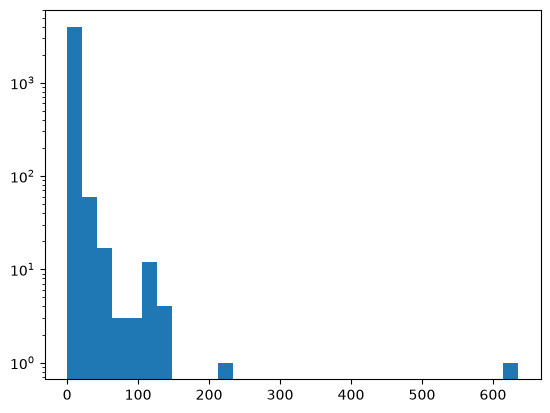

In [4]:
plt.hist(ks, bins=30,log=True)